# 1. Apply meta labeling


In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('../data/proccessed/btc-01_2021-09-2025-volume-15min.csv')

df['date_time'] = pd.to_datetime(df['date_time'], format='mixed')
df = df.drop_duplicates(subset='date_time', keep='last')
df = df.set_index('date_time').sort_index()
if getattr(df.index, "tz", None) is not None:
    df.index = df.index.tz_convert(None)

In [5]:
window_size = 50 

In [6]:
df['ema_20'] = df['close'].ewm(span=20, adjust=False).mean()
df['ema_50'] = df['close'].ewm(span=50, adjust = False).mean()

In [7]:
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
df['volatility'] = df['log_ret'].rolling(window=window_size).std()
df['serial_corr'] = df['log_ret'].rolling(window=window_size).corr(df['log_ret'].shift(1))
df.dropna(inplace=True)

In [8]:
df.head()

,tick_num,open,high,low,close,volume,cum_buy_volume,cum_ticks,cum_dollar_value,ema_20,ema_50,log_ret,volatility,serial_corr
date_time,,,,,,,,,,,,,,
2021-01-01 06:01:48.769,360776,29186.03,29213.40,29138.28,29206.38,291.495651,145.425358,8284,8.507014e+06,29215.502650,29190.239559,0.000697,0.002405,-0.156903
2021-01-01 06:15:21.615,370211,29206.38,29270.00,29205.32,29232.34,290.009553,179.109586,9435,8.478629e+06,29217.106208,29191.890557,0.000888,0.002363,-0.184963
2021-01-01 06:28:55.221,380917,29232.34,29232.34,29111.00,29124.90,291.139911,116.645006,10706,8.491706e+06,29208.324664,29189.263476,-0.003682,0.002407,-0.166871
2021-01-01 06:43:59.054,393639,29124.90,29191.00,29100.00,29190.46,290.001162,146.254532,12722,8.453472e+06,29206.623267,29189.310399,0.002248,0.002407,-0.209112
2021-01-01 06:54:00.617,401001,29190.46,29205.76,29100.59,29140.53,290.005362,135.427104,7362,8.459763e+06,29200.328671,29187.397442,-0.001712,0.002420,-0.226944


In [9]:
long_events  = df[(df['ema_20'] > df['ema_50']) & (df['ema_20'].shift(1) < df['ema_50'].shift(1))].index
short_events = df[(df['ema_20'] < df['ema_50']) & (df['ema_20'].shift(1) > df['ema_50'].shift(1))].index

long_events_series  = pd.Series(+1, index=long_events)
short_events_series = pd.Series(-1, index=short_events)

side = pd.concat([long_events_series, short_events_series]).sort_index()

t_events = side.index

In [10]:
from mlfinpy.labeling.labeling import add_vertical_barrier

vertical_barriers = add_vertical_barrier(t_events, df['close'], num_days=3)

In [11]:
len(t_events)

9232

In [12]:
from mlfinpy.labeling.labeling import get_events
from utils import get_daily_vol

pt_sl = [1,1]

daily_vol = get_daily_vol(df['close'], span0=window_size)
min_ret=0.005
triple_barrier_events = get_events(close=df['close'],
                                               t_events=t_events,
                                               pt_sl=pt_sl,
                                               target=daily_vol,
                                               min_ret=min_ret,
                                               num_threads=3,
                                               vertical_barrier_times=vertical_barriers,
                                               side_prediction=side)

triple_barrier_events.dropna(inplace=True)

ModuleNotFoundError: No module named 'utils'

In [118]:
from mlfinpy.labeling.labeling import get_bins

bins = get_bins(triple_barrier_events, df['close'])



In [119]:
data = bins.join(df, how='inner')

In [120]:
data.head()

,ret,trgt,bin,side,tick_num,open,high,low,close,volume,cum_buy_volume,cum_ticks,cum_dollar_value,ema_20,ema_50,log_ret,volatility,serial_corr
date_time,,,,,,,,,,,,,,,,,,
2021-01-02 20:06:08.636,-0.011862,0.011480,0,-1.0,3036274,32480.68,32579.48,32310.00,32322.00,290.653061,109.294348,4337,9.426818e+06,32839.652632,32854.492075,-0.004622,0.002748,0.116589
2021-01-02 22:21:35.317,0.016768,0.015594,1,1.0,3411413,31676.75,31866.55,31658.02,31836.77,290.009323,161.840022,8159,9.213669e+06,31626.080652,31613.876570,0.004936,0.004950,0.045755
2021-01-03 09:28:57.848,-0.009163,0.008575,0,-1.0,4430244,34100.57,34100.57,33870.40,33904.56,290.110935,93.024204,4778,9.860967e+06,34228.079684,34232.133581,-0.005117,0.003398,0.101906
2021-01-03 11:53:01.566,-0.009091,0.008625,0,1.0,4681994,34294.09,34377.72,34281.71,34364.49,290.181115,166.247838,5852,9.961095e+06,34052.741106,34036.340044,0.002038,0.003509,0.022425
2021-01-03 13:41:24.105,0.022662,0.021914,1,-1.0,4839661,33949.37,33966.98,33810.00,33900.00,293.145899,124.870171,4804,9.931981e+06,34125.873813,34134.307714,-0.001455,0.003129,0.141419


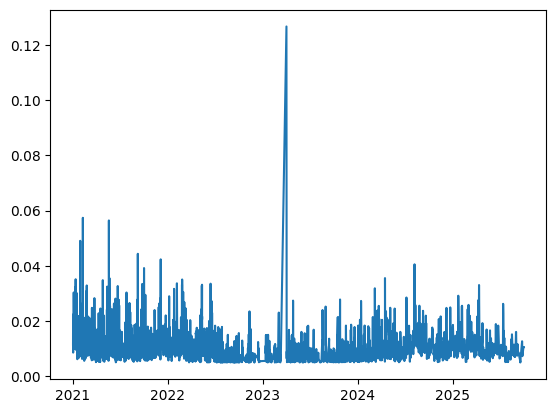

In [121]:
import matplotlib.pyplot as plt
plt.plot(data['trgt'])

## Split on train and test

The split should be time-wise 

In [122]:
features = ['serial_corr','volatility']
X = data[features]
y = data['bin']

split = int(len(data) * 0.7)

X_train, X_test, y_train, y_test = X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]

In [123]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Original strategy results

In [124]:
side.loc[y_test.index].value_counts()

-1    751
 1    749
Name: count, dtype: int64

In [125]:
from sklearn.metrics import classification_report

print(classification_report(y_test, side.loc[y_test.index].replace(-1, 0)))

              precision    recall  f1-score   support

           0       0.50      0.51      0.50       735
           1       0.52      0.51      0.51       765

    accuracy                           0.51      1500
   macro avg       0.51      0.51      0.51      1500
weighted avg       0.51      0.51      0.51      1500



## Secondary model's results

In [126]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.52      0.52       735
           1       0.54      0.54      0.54       765

    accuracy                           0.53      1500
   macro avg       0.53      0.53      0.53      1500
weighted avg       0.53      0.53      0.53      1500



In [127]:
from sklearn.metrics import roc_auc_score

train_proba = rf.predict_proba(X_train)[:, 1]  
test_proba  = rf.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_proba)
test_auc  = roc_auc_score(y_test,  test_proba)

print(f"\nAUC TRAIN = {train_auc:.4f}")
print(f"AUC TEST  = {test_auc:.4f}")


AUC TRAIN = 1.0000
AUC TEST  = 0.5302


In [128]:
cols = ['ret', 'trgt', 'bin', 'side', 'close']
test = data.loc[X_test.index, cols]
test['rf_pred'] = y_pred

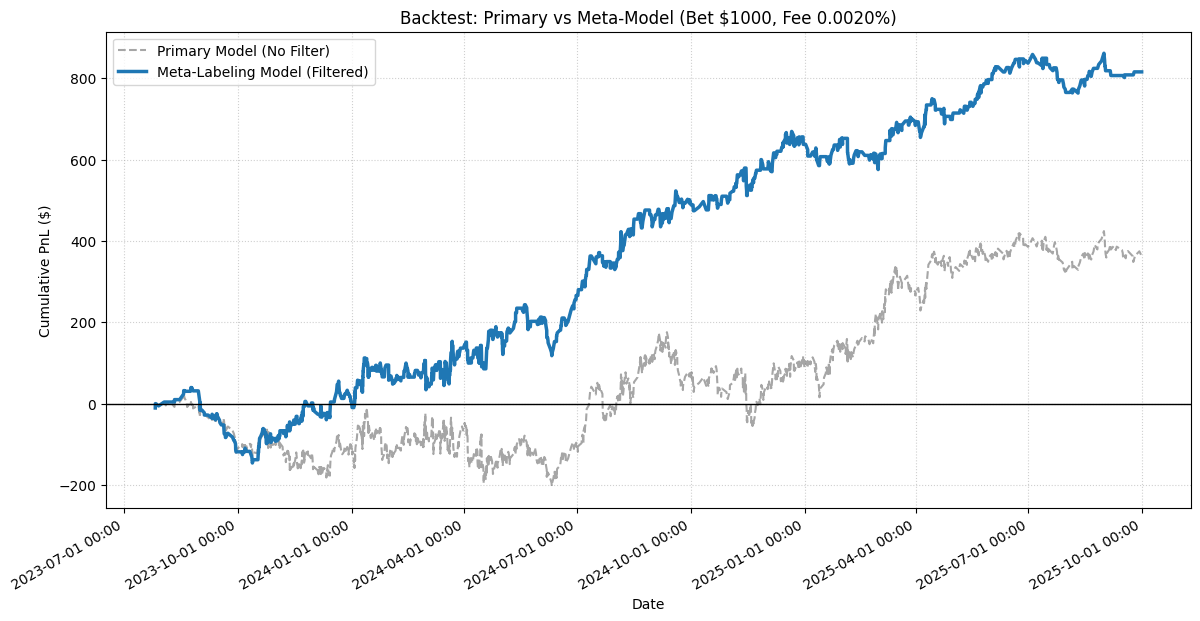

Total PnL Primary (with fees): $362.79
Total PnL Meta (with fees):    $815.67
Meta Trades Taken: 766 / 1500
Primary Trades Taken: 1500 / 1500


In [129]:
from utils import plot_backtest_performance
plot_backtest_performance(test, bet_size=1000)

# 2. Sample weights

In [130]:
from mlfinpy.sampling.concurrent import get_av_uniqueness_from_triple_barrier

In [131]:
avg_uniqueness = get_av_uniqueness_from_triple_barrier(triple_barrier_events, df['close'],3)

2025-12-01 01:36:49.066017 100.0% num_concurrent_events done after 0.01 minutes. Remaining 0.0 minutes.
2025-12-01 01:36:49.591773 100.0% _get_average_uniqueness done after 0.01 minutes. Remaining 0.0 minutes.


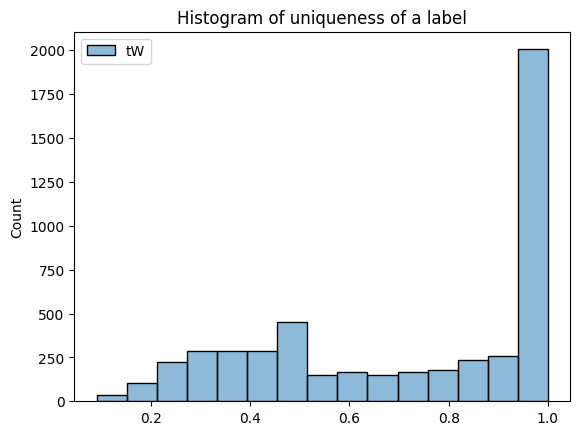

In [132]:
import seaborn as sns

plt.title('Histogram of uniqueness of a label')
sns.histplot(avg_uniqueness)
plt.show()

## Mean out of bag score

We set max_samples = avg_uniqueness as Marcos de Prado said

In [133]:
avg_uniq = avg_uniqueness.mean().iloc[0]
avg_uniq

0.7187582710015724

## Compute k-fold cross validation without shuffling

In [134]:
from utils import cv_rf_with_sample_weights

In [135]:
scores_side, scores_model = cv_rf_with_sample_weights(
    X=X,
    y=y,
    side=side,
    triple_barrier_events=triple_barrier_events,
    close_series=df['close'],
    avg_uniq=avg_uniq,
    use_return_weights=False,
    use_time_decay=False
)



========== Time-Series Cross Validation ==========


====== Fold 1 ======

>>> Primary Strategy (side)

              precision    recall  f1-score   support

           0       0.47      0.48      0.47       406
           1       0.49      0.48      0.49       426

    accuracy                           0.48       832
   macro avg       0.48      0.48      0.48       832
weighted avg       0.48      0.48      0.48       832

>>> RandomForest Model

              precision    recall  f1-score   support

           0       0.47      0.47      0.47       406
           1       0.50      0.50      0.50       426

    accuracy                           0.48       832
   macro avg       0.48      0.48      0.48       832
weighted avg       0.48      0.48      0.48       832


====== Fold 2 ======

>>> Primary Strategy (side)

              precision    recall  f1-score   support

           0       0.46      0.47      0.46       406
           1       0.48      0.47      0.48       426

 

The mean out-of-bag accuracy(60.27%) is higher than the cv accuracy(58.49%). To replicate this test just change the pt_sl from [1,1] to [2,1]

## Sample Weights by returns and average uniqueness

In [136]:
from mlfinpy.sample_weights.attribution import get_weights_by_return 

sample_weights = get_weights_by_return(triple_barrier_events, df['close'])

2025-12-01 01:36:52.386353 100.0% num_concurrent_events done after 0.0 minutes. Remaining 0.0 minutes.
2025-12-01 01:36:53.171588 100.0% _apply_weight_by_return done after 0.01 minutes. Remaining 0.0 minutes.


In [137]:
rf = RandomForestClassifier(random_state=42, oob_score=True, max_samples = avg_uniq)
rf.fit(data[features],data['bin'],sample_weight = sample_weights)
print(rf.oob_score_)

0.5131078647188313


In [138]:
scores_side, scores_model = cv_rf_with_sample_weights(
    X=X,
    y=y,
    side=side,
    triple_barrier_events=triple_barrier_events,
    close_series=df['close'],
    avg_uniq=avg_uniq,
    use_return_weights=True,
    use_time_decay=False
)


2025-12-01 01:36:54.502767 100.0% num_concurrent_events done after 0.0 minutes. Remaining 0.0 minutes.
2025-12-01 01:36:55.195405 100.0% _apply_weight_by_return done after 0.01 minutes. Remaining 0.0 minutes.



========== Time-Series Cross Validation ==========


====== Fold 1 ======

>>> Primary Strategy (side)

              precision    recall  f1-score   support

           0       0.47      0.48      0.47       406
           1       0.49      0.48      0.49       426

    accuracy                           0.48       832
   macro avg       0.48      0.48      0.48       832
weighted avg       0.48      0.48      0.48       832

>>> RandomForest Model

              precision    recall  f1-score   support

           0       0.47      0.47      0.47       406
           1       0.50      0.50      0.50       426

    accuracy                           0.49       832
   macro avg       0.49      0.49      0.49       832
weighted avg       0.49      0.49      0.49       832


====== Fold 2 ======

>>> Primary Strategy (side)

              precision    recall  f1-score   support

           0       0.46      0.47      0.46       406
           1       0.48      0.47      0.48       426

 

In [139]:
scores_side, scores_model = cv_rf_with_sample_weights(
    X=X,
    y=y,
    side=side,
    triple_barrier_events=triple_barrier_events,
    close_series=df['close'],
    avg_uniq=avg_uniq,
    use_return_weights=True,
    use_time_decay=True
)


2025-12-01 01:36:57.799703 100.0% num_concurrent_events done after 0.0 minutes. Remaining 0.0 minutes.
2025-12-01 01:36:58.528108 100.0% _apply_weight_by_return done after 0.01 minutes. Remaining 0.0 minutes.



========== Time-Series Cross Validation ==========


====== Fold 1 ======

>>> Primary Strategy (side)

              precision    recall  f1-score   support

           0       0.47      0.48      0.47       406
           1       0.49      0.48      0.49       426

    accuracy                           0.48       832
   macro avg       0.48      0.48      0.48       832
weighted avg       0.48      0.48      0.48       832

>>> RandomForest Model

              precision    recall  f1-score   support

           0       0.48      0.46      0.47       406
           1       0.50      0.52      0.51       426

    accuracy                           0.49       832
   macro avg       0.49      0.49      0.49       832
weighted avg       0.49      0.49      0.49       832


====== Fold 2 ======

>>> Primary Strategy (side)

              precision    recall  f1-score   support

           0       0.46      0.47      0.46       406
           1       0.48      0.47      0.48       426

 

For the standard [1,1] test we dont just a little in accuracy but we see bigger improvements for the [2,1] test

# 3. Cross Validation in finance

In [140]:

from purged_embargo_cv import PurgedKFold
from mlfinpy.sample_weights.attribution import get_weights_by_return, get_weights_by_time_decay

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, log_loss


t1 = triple_barrier_events['t1']

w_ret = get_weights_by_return(triple_barrier_events, df['close'])

decay=0.4
w_td  = get_weights_by_time_decay(
    triple_barrier_events,
    df['close'],
    num_threads=5,
    decay=decay,
    verbose=False
)

weights = (
    pd.Series(1.0, index=triple_barrier_events.index)
    * w_ret.reindex(triple_barrier_events.index)
    * w_td.reindex(triple_barrier_events.index)
)


cv = PurgedKFold(
    n_splits=5,
    t1=t1,
    pctEmbargo=0.01,
    verbose=True
)

clf = RandomForestClassifier(
    random_state=42,
    oob_score=True,
    max_samples=avg_uniq
)


all_y_true = []
all_y_pred = []
all_fold_logloss = []
all_fold_acc = []

for fold, (trn_idx, tst_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[trn_idx], X.iloc[tst_idx]
    y_train, y_test = y.iloc[trn_idx], y.iloc[tst_idx]

    w_train = weights.loc[y_train.index]
    # w_train = w_train / w_train.sum() * len(w_train)

    clf.fit(X_train, y_train, sample_weight=w_train)

    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    fold_acc = accuracy_score(y_test, y_pred)
    fold_logloss = log_loss(y_test, y_proba, labels=clf.classes_)

    all_fold_acc.append(fold_acc)
    all_fold_logloss.append(fold_logloss)

    print(f"\n=== Fold {fold} ===")
    print("Accuracy:", fold_acc)
    print("Log loss:", fold_logloss)
    print(classification_report(y_test, y_pred))


print("\n=== FINAL CLASSIFICATION REPORT ===")
print(classification_report(all_y_true, all_y_pred))
print("Avg accuracy:", np.mean(all_fold_acc))
print("Avg logloss:", np.mean(all_fold_logloss))


2025-12-01 01:37:02.233050 100.0% num_concurrent_events done after 0.0 minutes. Remaining 0.0 minutes.
2025-12-01 01:37:03.056788 100.0% _apply_weight_by_return done after 0.01 minutes. Remaining 0.0 minutes.



[Fold 1]
Test period: 2021-01-02 20:06:08.636000 to 2021-06-21 10:19:45.428000
Embargo until: 2021-06-26 17:16:06.472000
Test size: 1000
Train size after purge: 3947
Observations purged: 50

=== Fold 1 ===
Accuracy: 0.512
Log loss: 0.7514979030452082
              precision    recall  f1-score   support

           0       0.48      0.50      0.49       468
           1       0.54      0.52      0.53       532

    accuracy                           0.51      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.51      0.51      0.51      1000


[Fold 2]
Test period: 2021-06-21 10:25:03.634000 to 2022-03-30 01:43:16.459000
Embargo until: 2022-04-22 06:04:37.676000
Test size: 1000
Train size after purge: 3945
Observations purged: 52

=== Fold 2 ===
Accuracy: 0.508
Log loss: 0.7852285131618807
              precision    recall  f1-score   support

           0       0.51      0.48      0.49       498
           1       0.51      0.53      0.52       502

    a

We can see that the results are much lower than in the cross validtion part. The results are even lower when we apply embargo. There is an improvement when we use sample weights with time decay. When we're using more features like this: 'serial_corr','volatility','volume','cum_buy_volume','log_ret' we acheive a higher accuracy and a higher precision for 0 class (50% instead of 49%)

# 4. Fractionally differentiated

In [141]:
from utils import add_meta_features

df = add_meta_features(df,window_size)

In [142]:
df.head()

,tick_num,open,high,low,close,volume,cum_buy_volume,cum_ticks,cum_dollar_value,ema_20,...,serial_corr,vol_imbalance,avg_trade_size,amihud_illiquidity,efficiency_ratio,z_score_ema50,rsi,roll_skew,roll_kurt,vol_ratio
date_time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 18:20:31.247,1044828,29220.00,29245.01,29171.26,29192.04,290.013567,133.972458,8006,8.471627e+06,29183.461973,...,-0.089776,-0.076095,0.036225,1.130051e-10,0.137910,-0.330985,45.051667,0.472950,0.782340,1.328697
2021-01-01 18:26:52.008,1053592,29192.04,29192.31,29007.07,29016.50,290.003283,114.407944,8764,8.439935e+06,29167.560832,...,-0.070591,-0.210989,0.033090,7.146306e-10,0.199621,-1.651679,35.590116,0.276659,0.745266,1.476753
2021-01-01 18:30:24.278,1058325,29016.50,29072.81,29000.00,29000.00,291.160984,114.644408,4733,8.451452e+06,29151.602658,...,-0.052230,-0.212502,0.061517,6.730249e-11,0.170476,-1.677279,33.104600,0.276054,0.959341,1.466312
2021-01-01 18:34:47.389,1064480,29000.00,29103.18,28960.92,29083.00,290.048892,153.151509,6155,8.420574e+06,29145.069071,...,-0.052158,0.056039,0.047124,3.394045e-10,0.134709,-1.001457,40.139995,0.234569,0.718478,1.505008
2021-01-01 18:41:46.060,1070950,29083.00,29083.00,28950.00,28950.00,290.397511,111.910402,6470,8.425872e+06,29126.491065,...,-0.096214,-0.229261,0.044884,5.439920e-10,0.127742,-1.858321,35.394014,0.296182,0.691578,1.579266


In [143]:
from mlfinpy.util.frac_diff import frac_diff_ffd

non_stationary_features = ['open','high','low','close','cum_dollar_value']
d = 0.38

for col in non_stationary_features:
    df[col + '_frac'] = frac_diff_ffd(df[[col]], diff_amt=d)

features = [
    'serial_corr','volatility','tick_num','open_frac','high_frac','low_frac','close_frac','volume',
    'cum_buy_volume','cum_ticks','cum_dollar_value_frac','vol_imbalance',
    'avg_trade_size','amihud_illiquidity','log_ret','efficiency_ratio',
    'z_score_ema50','rsi','roll_skew','roll_kurt','vol_ratio'
]
df[features]

,serial_corr,volatility,tick_num,open_frac,high_frac,low_frac,close_frac,volume,cum_buy_volume,cum_ticks,...,vol_imbalance,avg_trade_size,amihud_illiquidity,log_ret,efficiency_ratio,z_score_ema50,rsi,roll_skew,roll_kurt,vol_ratio
date_time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 18:20:31.247000,-0.089776,0.002283,1044828,NaN,NaN,NaN,NaN,290.013567,133.972458,8006,...,-0.076095,0.036225,1.130051e-10,-0.000957,0.137910,-0.330985,45.051667,0.472950,0.782340,1.328697
2021-01-01 18:26:52.008000,-0.070591,0.002422,1053592,NaN,NaN,NaN,NaN,290.003283,114.407944,8764,...,-0.210989,0.033090,7.146306e-10,-0.006031,0.199621,-1.651679,35.590116,0.276659,0.745266,1.476753
2021-01-01 18:30:24.278000,-0.052230,0.002369,1058325,NaN,NaN,NaN,NaN,291.160984,114.644408,4733,...,-0.212502,0.061517,6.730249e-11,-0.000569,0.170476,-1.677279,33.104600,0.276054,0.959341,1.466312
2021-01-01 18:34:47.389000,-0.052158,0.002411,1064480,NaN,NaN,NaN,NaN,290.048892,153.151509,6155,...,0.056039,0.047124,3.394045e-10,0.002858,0.134709,-1.001457,40.139995,0.234569,0.718478,1.505008
2021-01-01 18:41:46.060000,-0.096214,0.002384,1070950,NaN,NaN,NaN,NaN,290.397511,111.910402,6470,...,-0.229261,0.044884,5.439920e-10,-0.004584,0.127742,-1.858321,35.394014,0.296182,0.691578,1.579266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-30 20:54:56.617205,-0.053583,0.001893,64380826,5093.355465,5490.844952,5295.316774,5681.802545,290.006530,190.293610,53089,...,0.312340,0.005463,1.391703e-10,0.004619,0.058569,1.990248,68.297850,0.490207,-0.252961,1.253382
2025-09-30 21:13:07.644125,-0.106677,0.001892,64422962,5681.810278,5433.481632,5588.389777,5302.353512,290.065250,157.701030,42136,...,0.087349,0.006884,4.589280e-11,-0.001527,0.059194,1.598700,69.912482,0.490513,-0.250131,1.355671
2025-09-30 21:39:52.695186,-0.084740,0.001878,64483171,5302.370956,5142.007865,5127.858674,5226.605143,290.036460,126.936190,60209,...,-0.124688,0.004817,1.824406e-11,-0.000605,0.027425,1.412795,73.519002,0.564284,-0.119798,1.369166


/home/octa/miniconda3/envs/disertatie/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/octa/miniconda3/envs/disertatie/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/octa/miniconda3/envs/disertatie/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/octa/miniconda3/envs/disertatie/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/octa/miniconda3/envs/disertatie/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/octa/miniconda3/envs/disertatie/li

<Axes: >

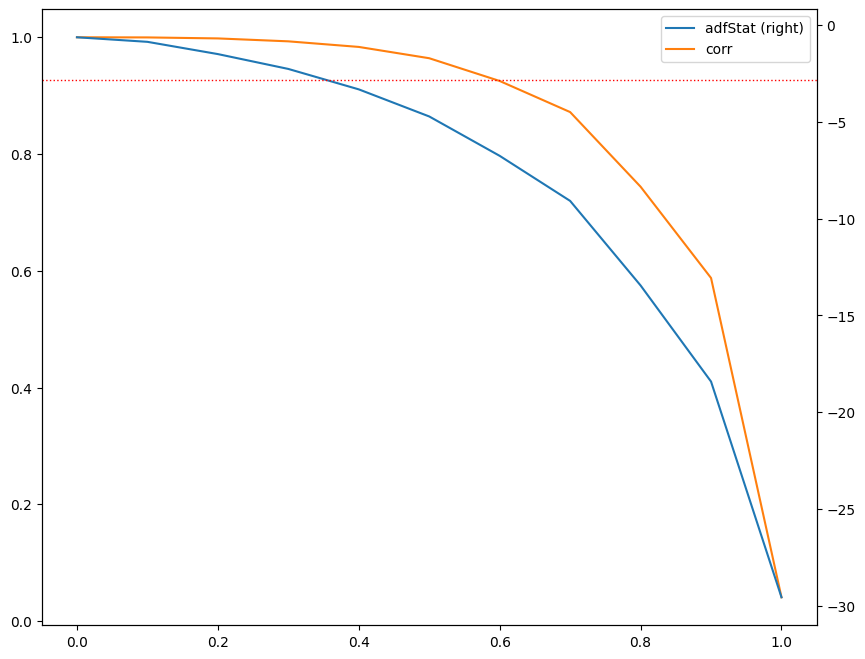

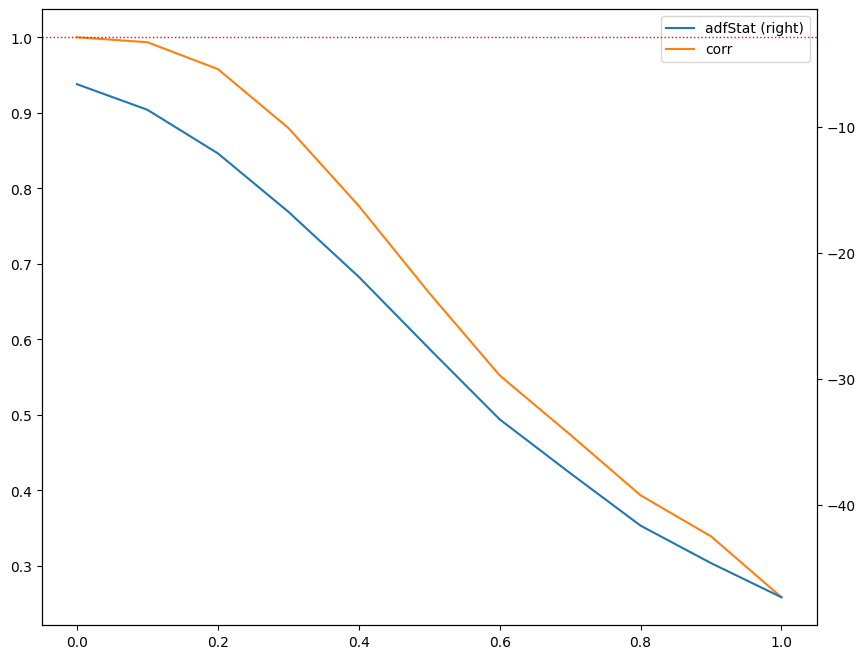

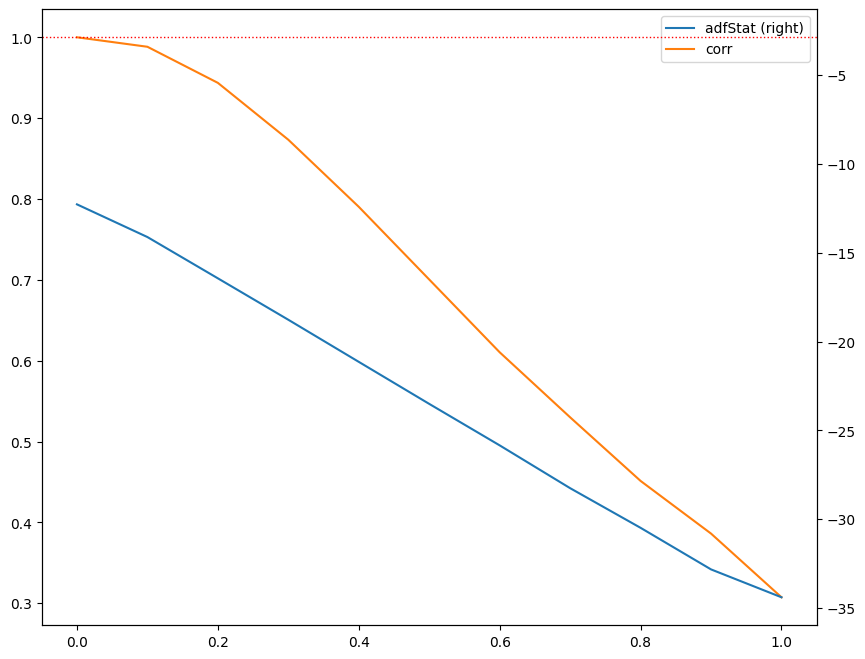

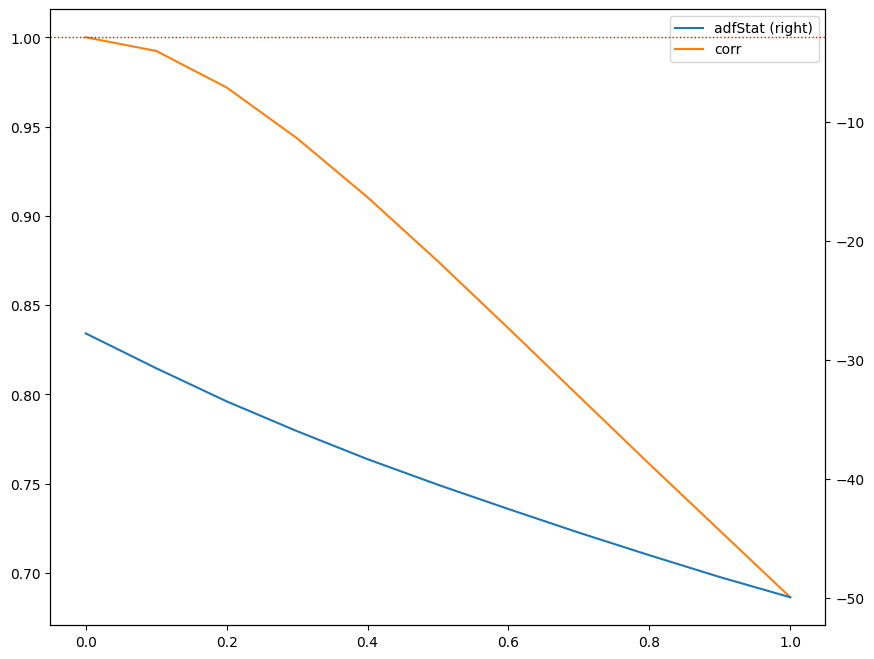

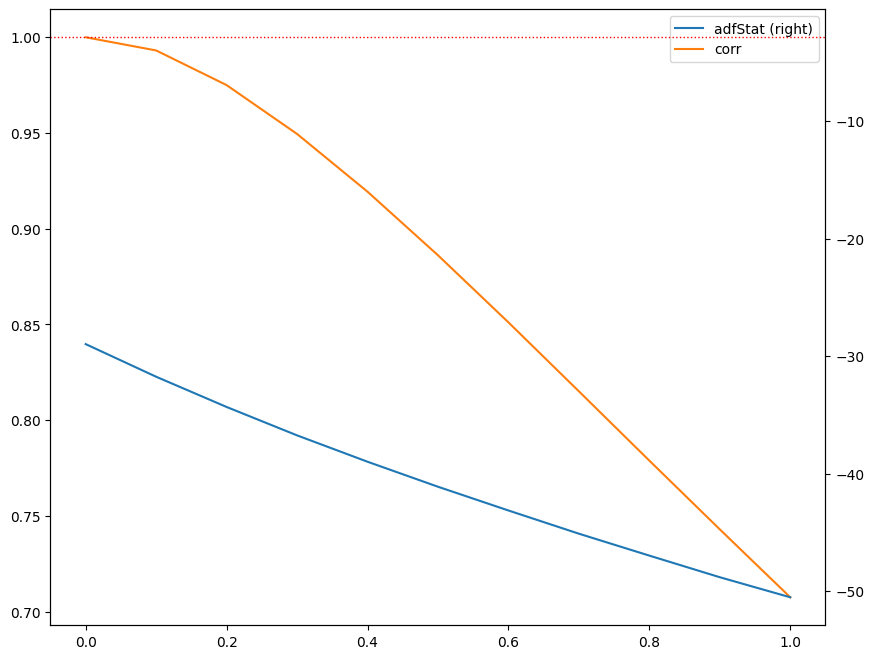

In [144]:
from mlfinpy.util.frac_diff import plot_min_ffd

plot_min_ffd(df[['cum_dollar_value']].rename(columns={'cum_dollar_value':'close'}))
plot_min_ffd(df[['cum_ticks']].rename(columns={'cum_ticks':'close'}))
plot_min_ffd(df[['tick_num']].rename(columns={'tick_num':'close'}))
plot_min_ffd(df[['vol_imbalance']].rename(columns={'vol_imbalance':'close'}))
plot_min_ffd(df[['volume']].rename(columns={'volume':'close'}))

We'll try to add fractionally differentiated to the non-stationary features. All with d=0.38

In [145]:
non_stationary_features = ['open','high','low','close','cum_dollar_value']

In [146]:
from mlfinpy.util.frac_diff import frac_diff_ffd

non_stationary_features = ['open','high','low','close','cum_dollar_value']
d = 0.38

for col in non_stationary_features:
    df[col + '_frac'] = frac_diff_ffd(df[[col]], diff_amt=d)



In [292]:
features = [
    'serial_corr','volatility','tick_num','open_frac','high_frac','low_frac','close_frac','volume',
    'cum_buy_volume','cum_ticks','cum_dollar_value_frac','side',#'log_ret,'rsi','roll_skew','roll_kurt','vol_ratio','z_score_ema50','efficiency_ratio','vol_imbalance','avg_trade_size','amihud_illiquidity'
]

features = ['high_frac','low_frac','close_frac','open_frac','volume','side']
# features=['open_frac','low_frac','high_frac','close_frac','log_ret']
# features = [
#     'serial_corr','volatility','tick_num','open_frac','high_frac','low_frac','close_frac','volume',
#     'cum_buy_volume','cum_ticks','cum_dollar_value_frac','log_ret','side'
# ]
# features = ['volatility','volume','open_frac','low_frac','close_frac','tick_num','serial_corr']
#'rsi','roll_skew','roll_kurt','vol_ratio','z_score_ema50','efficiency_ratio','vol_imbalance','avg_trade_size','amihud_illiquidity'

# 5. Feature Importance

We're using MDA for feature importance

TODO: use select k best function

In [293]:
pt_sl = [1,1]

daily_vol = get_daily_vol(df['close'], span0=window_size)
min_ret=0.005
triple_barrier_events = get_events(close=df['close'],
                                               t_events=t_events,
                                               pt_sl=pt_sl,
                                               target=daily_vol,
                                               min_ret=min_ret,
                                               num_threads=3,
                                               vertical_barrier_times=vertical_barriers,
                                               side_prediction=side)

triple_barrier_events.dropna(inplace=True)
bins = get_bins(triple_barrier_events, df['close'])
data = bins.join(df, how='inner')


2025-12-01 02:26:49.169325 100.0% triple_barriers done after 0.02 minutes. Remaining 0.0 minutes..


Starting Cross-Validation MDA Feature Importance...

[Fold 1]
Test period: 2021-01-02 20:06:08.636000 to 2021-06-21 10:19:45.428000
Embargo until: 2021-06-26 17:16:06.472000
Test size: 1000
Train size after purge: 3947
Observations purged: 50
Processing Fold 1...

[Fold 2]
Test period: 2021-06-21 10:25:03.634000 to 2022-03-30 01:43:16.459000
Embargo until: 2022-04-22 06:04:37.676000
Test size: 1000
Train size after purge: 3945
Observations purged: 52
Processing Fold 2...

[Fold 3]
Test period: 2022-03-29 19:54:45.711000 to 2022-11-10 13:54:03.133000
Embargo until: 2022-11-15 04:30:16.612000
Test size: 999
Train size after purge: 3943
Observations purged: 55
Processing Fold 3...

[Fold 4]
Test period: 2022-11-10 14:04:42.713000 to 2024-03-11 07:00:08.580000
Embargo until: 2024-03-21 12:31:38.936000
Test size: 999
Train size after purge: 3948
Observations purged: 50
Processing Fold 4...

[Fold 5]
Test period: 2024-03-12 00:57:04.913000 to 2025-09-30 19:51:30.144275
Embargo until: 2025-09

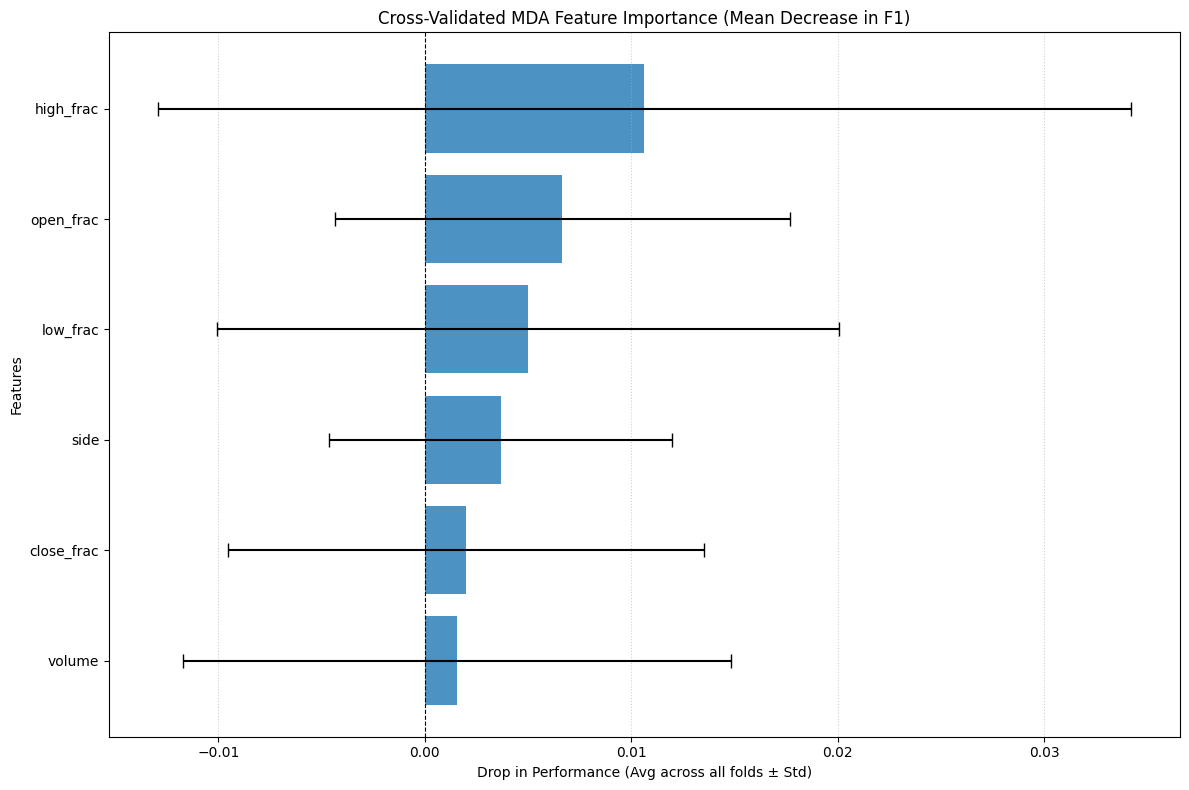


=== Top Consistent Features (CV-MDA) ===
               Feature  Importance_Mean  Importance_Std
high_frac    high_frac         0.010641        0.023583
open_frac    open_frac         0.006669        0.011031
low_frac      low_frac         0.004994        0.015056
side              side         0.003672        0.008299
close_frac  close_frac         0.001982        0.011533
volume          volume         0.001568        0.013261


In [294]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# ==========================================
# 1. SETUP (Date și CV)
# ==========================================
# Asigură-te că X, y și cv (PurgedKFold) sunt definite anterior
X = data[features]
y = data['bin']

# DataFrame pentru a stoca importanța fiecărui feature în fiecare fold
fold_importance_df = pd.DataFrame(index=X.columns)

print(f"Starting Cross-Validation MDA Feature Importance...")

# ==========================================
# 2. LOOP PRIN FOLDURI
# ==========================================
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    print(f"Processing Fold {fold}...")
    
    # Split Date
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Dacă folosești sample_weights, asigură-te că le extragi și aici
    # w_train = weights.loc[y_train.index]
    
    # Inițializare Model (Model nou pentru fiecare fold!)
    rf = RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        class_weight='balanced_subsample',
        max_samples=avg_unique if 'avg_unique' in globals() else None,
        n_jobs=-1
    )
    
    # Antrenare
    rf.fit(X_train, y_train) # Adaugă sample_weight=w_train dacă ai greutăți
    
    # Calcul MDA pe setul de TEST al acestui fold
    # Scoring: Folosește 'f1' sau 'precision' (ce te interesează mai mult)
    result = permutation_importance(
        rf, X_test, y_test,
        n_repeats=5,        # 5 repetări per fold e suficient (total 5x5=25)
        random_state=42,
        n_jobs=-1,
        scoring='precision'        # Recomand F1 pentru date dezechilibrate
    )
    
    # Stocăm media scăderii performanței pentru acest fold
    fold_importance_df[f'Fold_{fold}'] = result.importances_mean

# ==========================================
# 3. AGREGARE REZULTATE
# ==========================================
# Calculăm media și deviația standard peste toate cele 5 folduri
results_df = pd.DataFrame({
    'Feature': fold_importance_df.index,
    'Importance_Mean': fold_importance_df.mean(axis=1),
    'Importance_Std': fold_importance_df.std(axis=1) # Arată stabilitatea în timp
})

# Sortare
results_df = results_df.sort_values(by='Importance_Mean', ascending=True)

# ==========================================
# 4. PLOTARE
# ==========================================
plt.figure(figsize=(12, 8))

# Barele de eroare (xerr) arată acum variația temporală (între folduri)
plt.barh(
    results_df['Feature'], 
    results_df['Importance_Mean'], 
    xerr=results_df['Importance_Std'], 
    color='#1f77b4', 
    alpha=0.8,
    capsize=5
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Cross-Validated MDA Feature Importance (Mean Decrease in F1)')
plt.xlabel('Drop in Performance (Avg across all folds ± Std)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n=== Top Consistent Features (CV-MDA) ===")
print(results_df.sort_values(by='Importance_Mean', ascending=False))

Starting Time-Wise Feature Selection over 5 folds...
Processing Fold 1/5...
Processing Fold 2/5...
Processing Fold 3/5...
Processing Fold 4/5...
Processing Fold 5/5...


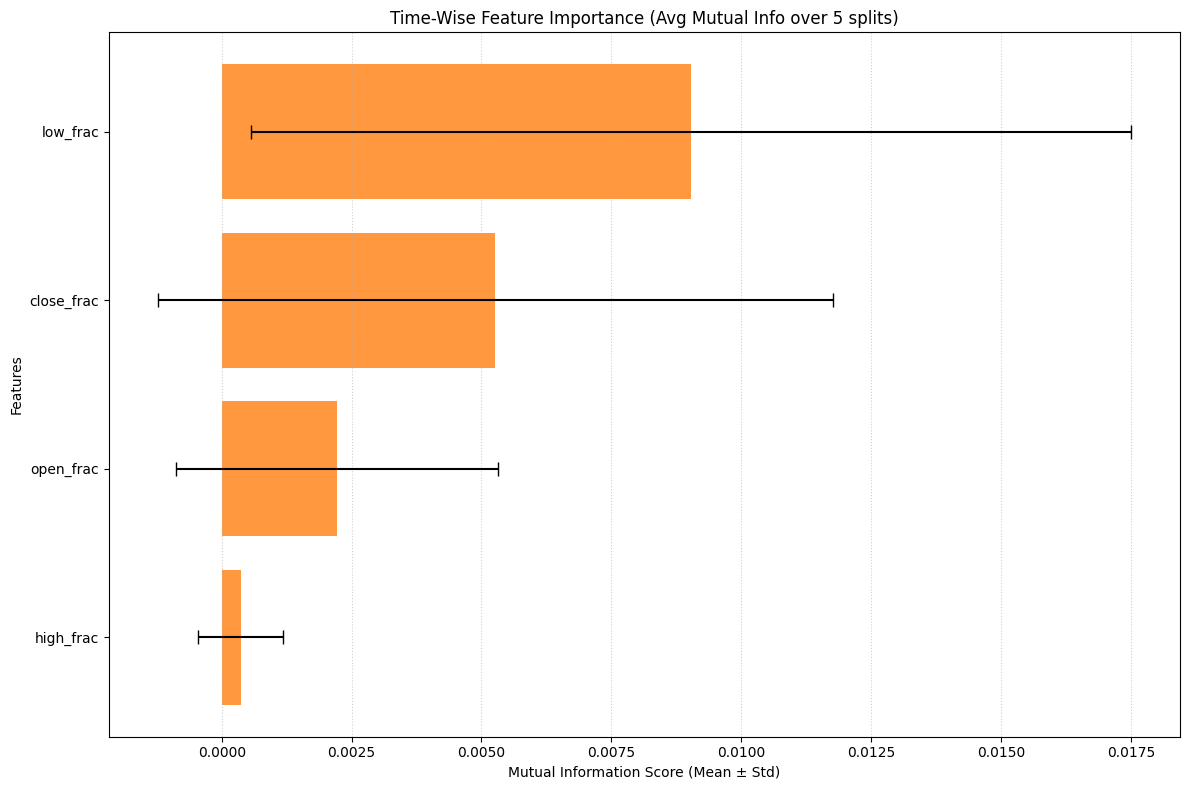


=== Top Consistent Features (Time-Wise) ===
               Feature  Score_Mean  Score_Std
low_frac      low_frac    0.009036   0.008474
close_frac  close_frac    0.005266   0.006501
open_frac    open_frac    0.002217   0.003095
high_frac    high_frac    0.000365   0.000816


In [288]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import TimeSeriesSplit

# 1. Setup Data
# Ensure date_time index is sorted for Time Series Split
if not data.index.is_monotonic_increasing:
    data = data.sort_index()

data_clean = data.dropna()
X = data_clean[features]
y = data_clean['bin']

# 2. Configure Time-Series Split
# We use 5 splits. This creates an "expanding window" effect.
# Fold 1: Train on first 16% -> Score
# Fold 2: Train on first 33% -> Score
# ...
# Fold 5: Train on first 83% -> Score
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

print(f"Starting Time-Wise Feature Selection over {n_splits} folds...")

# DataFrame to store scores for each fold
fold_scores = pd.DataFrame(index=X.columns)

# 3. Iterate through Time Wise Folds
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"Processing Fold {fold + 1}/{n_splits}...")
    
    # We only care about the Training set of the fold to calculate MI
    # (We want to know what the model WOULD have learned at that point in time)
    X_fold_train = X.iloc[train_index]
    y_fold_train = y.iloc[train_index]
    
    # Calculate Mutual Information for this time period
    # random_state ensures reproducibility
    mi_scores = mutual_info_classif(
        X_fold_train, 
        y_fold_train, 
        random_state=42
    )
    
    # Store results
    fold_scores[f'Fold_{fold+1}'] = mi_scores

# 4. Aggregate Results (Mean & Std Dev)
# Mean tells us the average power.
# Std tells us the stability (Lower is better).
results_df = pd.DataFrame({
    'Feature': fold_scores.index,
    'Score_Mean': fold_scores.mean(axis=1),
    'Score_Std': fold_scores.std(axis=1)
})

# Sort by Mean Score
results_df = results_df.sort_values(by='Score_Mean', ascending=True)

# 5. Plotting with Error Bars
plt.figure(figsize=(12, 8))

# We use xerr to show standard deviation (instability)
plt.barh(
    results_df['Feature'], 
    results_df['Score_Mean'], 
    xerr=results_df['Score_Std'], 
    color='#ff7f0e', 
    alpha=0.8,
    capsize=5  # Adds caps to error bars
)

plt.title(f'Time-Wise Feature Importance (Avg Mutual Info over {n_splits} splits)')
plt.xlabel('Mutual Information Score (Mean ± Std)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Display Top Features numerically
print("\n=== Top Consistent Features (Time-Wise) ===")
print(results_df.sort_values(by='Score_Mean', ascending=False))